## 06 - TensorFlow Core Basics (Learn This First)

This notebook is the **first step** in your TensorFlow learning sequence.

Recommended order:
1. Tensor creation and inspection (`tf.constant`, `tf.zeros`, `tf.ones`, `tf.range`, `tf.shape`)
2. Mutable state (`tf.Variable`, `assign`, `assign_add`)
3. Tensor transformation (`tf.reshape`, `tf.cast`, slicing, broadcasting)
4. Core math (`tf.add`, `tf.matmul`, `tf.reduce_mean`, `tf.math.*`)
5. Autodiff (`tf.GradientTape`)
6. Basic modeling blocks (`tf.keras.layers.Layer`, `tf.keras.Model`)
7. Safety patterns (`tf.math.is_finite`, `tf.where`, `tf.clip_by_value`)

---

## TensorFlow API Tutorial (Only `tf` Classes/Functions)

### 1) `tf.constant`
Documentation: https://www.tensorflow.org/api_docs/python/tf/constant  
Use case: immutable values (input examples, masks, fixed lookup values).

Do:
- Set explicit `dtype` when precision matters.
- Use it for values that should never be updated.

Don't:
- Use `tf.constant` for trainable weights.

Tips and tricks:
- Prefer `tf.constant([...], dtype=tf.float32)` to avoid accidental `float64`/`int64` promotion.

Edge condition:
- Ragged nested Python lists can produce shape errors. Keep rectangular shape unless using ragged tensors.

### 2) `tf.Variable`
Documentation: https://www.tensorflow.org/api_docs/python/tf/Variable  
Use case: trainable parameters and mutable model state.

Do:
- Update with `assign` / `assign_add`.
- Keep variable dtypes consistent with optimizer and model.

Don't:
- Recreate variables inside training loops.

Tips and tricks:
- Initialize with realistic scales to avoid exploding/vanishing gradients.

Edge condition:
- Integer variables are not differentiable for gradient-based optimization.

### 3) `tf.GradientTape`
Documentation: https://www.tensorflow.org/api_docs/python/tf/GradientTape  
Use case: compute gradients for custom training loops and advanced losses.

Do:
- Ensure watched tensors are floating point.
- Use `persistent=True` only when multiple gradient calls are required.

Don't:
- Expect gradients through nondifferentiable ops (e.g., hard thresholding) without custom gradients.

Tips and tricks:
- Use nested tapes for higher-order derivatives.

Edge condition:
- If gradient is `None`, check: tensor dtype, disconnected graph, and whether variable/tensor was watched.

### 4) `tf.keras.layers.Layer` and `tf.keras.Model`
Documentation:  
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/Layer  
- https://www.tensorflow.org/api_docs/python/tf/keras/Model

Use case:
- `Layer`: reusable building block.
- `Model`: trainable end-to-end architecture.

Do:
- Create weights in `build`.
- Keep forward logic in `call`.

Don't:
- Create new variables inside each `call` execution.

Tips and tricks:
- Validate output shape early with a dummy input.

Edge condition:
- Dynamic shape assumptions can break when batch size changes.

### 5) Numerical safety (`tf.math.is_finite`, `tf.where`, `tf.clip_by_value`)
Documentation:  
- https://www.tensorflow.org/api_docs/python/tf/math/is_finite  
- https://www.tensorflow.org/api_docs/python/tf/where  
- https://www.tensorflow.org/api_docs/python/tf/clip_by_value

Use case: defend training against NaN/Inf and unstable ranges.

Do:
- Check and sanitize tensors before loss/gradient-critical operations.

Don't:
- Ignore first NaN occurrence; stop and inspect immediately.

Tips and tricks:
- Clip inputs to `log`, division, and exponentials.

Edge condition:
- Replacing invalid values hides root causes if used without logging.

---

## Summary (06)

After finishing this notebook, you should be able to:
- Build and manipulate tensors safely.
- Write custom gradient-based updates with `tf.GradientTape`.
- Create custom layers/models with stable forward logic.
- Detect and mitigate common numerical failures.

Continue to **07** only after these are comfortable in eager execution.

In [1]:
# Standalone notebook setup (required imports)
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.22.0-dev0+selfbuilt
NumPy: 2.4.2


In [14]:
# Quick API practice (06): core tf classes/functions with inline comments

# 1) Immutable tensor for fixed values
x_const = tf.constant([[1.0, 2.0], [3.0, 4.0]], dtype=tf.float32)

# 2) Mutable variable for trainable state
w_var = tf.Variable([[0.5], [1.5]], dtype=tf.float32)

# 3) Core tensor transformation and shape handling
x_flat = tf.reshape(x_const, [-1])  # Flatten to 1D for demonstration
x_cast = tf.cast(x_flat, tf.float32)  # Keep explicit dtype for stability

# 4) GradientTape for custom gradient computation
with tf.GradientTape() as tape:
    y_pred = tf.matmul(x_const, w_var)  # Linear projection
    loss = tf.reduce_mean((y_pred - 1.0) ** 2)  # Simple MSE-like scalar loss

grads = tape.gradient(loss, w_var)

# 5) Safety checks before applying updates
grad_is_finite = tf.reduce_all(tf.math.is_finite(grads))
if grad_is_finite:
    # Gradient descent update: w <- w - lr * grad
    w_var.assign_sub(0.1 * grads)
else:
    # Replace invalid gradient values to avoid poisoning state
    safe_grads = tf.where(tf.math.is_finite(grads), grads, tf.zeros_like(grads))
    w_var.assign_sub(0.1 * safe_grads)

print('x_const shape:', x_const.shape)
print('Initial flattened tensor:', x_flat.numpy())
print('Loss:', float(loss.numpy()))
print('Gradient finite:', bool(grad_is_finite.numpy()))
print('Updated weights:', w_var.numpy())

x_const shape: (2, 2)
Initial flattened tensor: [1. 2. 3. 4.]
Loss: 24.25
Gradient finite: True
Updated weights: [[-1.7      ]
 [-1.6000001]]


## Code Logic Walkthrough (06)

This notebook is organized as progressive building blocks. The sections below explain the logic used in each code block.

1. **Standalone setup**
   - Imports TensorFlow, NumPy, and Matplotlib.
   - Sets random seeds to keep results reproducible.

2. **Safe gradient computation**
   - Demonstrates how raw math can become numerically unstable.
   - Uses clipping and `tf.math.is_finite` checks to prevent invalid values from silently propagating.

3. **NaN/Inf edge cases**
   - Creates common invalid-value scenarios (division by zero, invalid logs, overflow).
   - Shows detection (`is_nan`, `is_inf`, `is_finite`) and safe replacement strategies.

4. **Custom training loop (linear regression)**
   - Implements forward pass, MSE loss, gradient computation, and weight updates manually.
   - Tracks loss over epochs and visualizes convergence.

5. **Custom model assembly**
   - Builds a `SimpleNN` by composing custom dense/dropout blocks.
   - Validates output shape and parameter count to verify architecture correctness.

6. **Custom layers and model internals**
   - Implements a custom dense layer (`build` for weights, `call` for forward pass).
   - Adds a reusable activation+dropout style layer.

7. **Automatic differentiation**
   - Uses `tf.GradientTape` for single-variable, multi-variable, and higher-order derivatives.
   - Verifies gradients against expected analytic derivatives.

8. **Constants vs variables**
   - Explains mutability and trainability differences.
   - Demonstrates safe assignment/update patterns for model state.

9. **Tensor mechanics (create, index, math, reshape)**
   - Covers rank/shape intuition, slicing/indexing, broadcasting-style arithmetic, and reshape flow.
   - Bridges NumPy arrays to TensorFlow tensors.

10. **Device visibility and runtime context**
   - Enumerates available CPU/GPU devices.
   - Serves as environment validation before larger model workloads.

Use this notebook as a "core mechanics" reference: each section isolates one concept while reusing the same TensorFlow execution model.

In [2]:
# 4. Practical example: Safe gradient computation
print("\n\nPractical Example: Safe Gradient Computation")

# Problem: Computing gradient of a loss that can produce NaN
x = tf.Variable(10.0)  # Very large value

with tf.GradientTape() as tape:
    # This loss can produce Inf if x is very large
    loss = tf.math.log(x)  # Vulnerable to overflow

gradient = tape.gradient(loss, x)
print(f"x = {x.numpy()}")
print(f"loss = log(x) = {loss.numpy()}")
print(f"gradient = {gradient.numpy()}")

# Safe version with checks
print("\n\nSafe Computation with Checks:")

def safe_loss_computation(x, verbose=True):
    """Compute loss with safety checks"""
    # Clip input to valid range
    x_safe = tf.clip_by_value(x, 1e-7, 1e10)
    
    with tf.GradientTape() as tape:
        tape.watch(x_safe)
        loss = tf.math.log(x_safe)
    
    gradient = tape.gradient(loss, x_safe)
    
    # Check for invalid values
    loss_valid = tf.math.is_finite(loss)
    gradient_valid = tf.math.is_finite(gradient)
    
    if verbose:
        print(f"  x (original) = {x.numpy()}")
        print(f"  x (clipped) = {x_safe.numpy()}")
        print(f"  loss = {loss.numpy()}, valid = {loss_valid.numpy()}")
        print(f"  gradient = {gradient.numpy()}, valid = {gradient_valid.numpy()}")
    
    return loss, gradient, loss_valid and gradient_valid

# Test with problematic values
print("Test 1: Normal value")
loss1, grad1, valid1 = safe_loss_computation(tf.Variable(2.0))

print("\nTest 2: Very large value (would overflow)")
loss2, grad2, valid2 = safe_loss_computation(tf.Variable(1e20))

print("\nTest 3: Very small value (would underflow)")
loss3, grad3, valid3 = safe_loss_computation(tf.Variable(1e-20))



Practical Example: Safe Gradient Computation
x = 10.0
loss = log(x) = 2.3025851249694824
gradient = 0.10000000149011612


Safe Computation with Checks:
Test 1: Normal value
  x (original) = 2.0
  x (clipped) = 2.0
  loss = 0.6931471824645996, valid = True
  gradient = 0.5, valid = True

Test 2: Very large value (would overflow)
  x (original) = 1.0000000200408773e+20
  x (clipped) = 10000000000.0
  loss = 23.025850296020508, valid = True
  gradient = 1.000000013351432e-10, valid = True

Test 3: Very small value (would underflow)
  x (original) = 9.999999682655225e-21
  x (clipped) = 1.0000000116860974e-07
  loss = -16.11809539794922, valid = True
  gradient = 10000000.0, valid = True


In [3]:
# Edge Cases: NaN and Inf
print("=" * 60)
print("Edge Cases: NaN and Inf Values")
print("=" * 60)

# 1. Common sources of NaN and Inf
print("\nCommon sources of NaN/Inf:")

# Division by zero
result_inf = np.float64(1.0) / np.float64(0.0)
result_ninf = np.float64(-1.0) / np.float64(0.0)
print(f"  1.0 / 0.0 = {result_inf}")
print(f"  -1.0 / 0.0 = {result_ninf}")

# Log of negative
result_nan = tf.math.log(-1.0)
print(f"  log(-1.0) = {result_nan}")

# 0/0
result_nan2 = np.float64(0.0) / np.float64(0.0)
print(f"  0.0 / 0.0 = {result_nan2}")

# Overflow - use float32 max value
large_value = tf.constant(3.4e38, dtype=tf.float32)
result_overflow = large_value * 10
print(f"  1e308 * 10 = {result_overflow}")

# 2. Detecting NaN and Inf
print("\n\nDetecting NaN and Inf:")

tensor_with_issues = tf.constant([1.0, float('nan'), 2.0, float('inf'), -5.0])
print(f"Tensor: {tensor_with_issues}")

is_nan = tf.math.is_nan(tensor_with_issues)
is_inf = tf.math.is_inf(tensor_with_issues)
is_finite = tf.math.is_finite(tensor_with_issues)

print(f"is_nan: {is_nan}")
print(f"is_inf: {is_inf}")
print(f"is_finite: {is_finite}")

# Count invalid values
num_nan = tf.reduce_sum(tf.cast(tf.math.is_nan(tensor_with_issues), tf.int32))
num_inf = tf.reduce_sum(tf.cast(tf.math.is_inf(tensor_with_issues), tf.int32))
print(f"Number of NaN values: {num_nan}")
print(f"Number of Inf values: {num_inf}")

# 3. Replacing NaN and Inf with safe values
print("\n\nReplacing NaN and Inf:")

# Method 1: Using tf.where
safe_tensor1 = tf.where(
    tf.math.is_finite(tensor_with_issues),
    tensor_with_issues,
    tf.constant(0.0)
)
print(f"Replace with 0.0: {safe_tensor1}")

# Method 2: Using tf.clip_by_value
safe_tensor2 = tf.clip_by_value(tensor_with_issues, -1e6, 1e6)
print(f"Clip to [-1e6, 1e6]: {safe_tensor2}")

# Method 3: Custom function
def replace_invalid_values(tensor, replacement=0.0):
    """Replace NaN and Inf with a replacement value"""
    return tf.where(
        tf.math.is_finite(tensor),
        tensor,
        tf.fill(tf.shape(tensor), replacement)
    )

safe_tensor3 = replace_invalid_values(tensor_with_issues, replacement=0.5)
print(f"Replace with 0.5: {safe_tensor3}")

Edge Cases: NaN and Inf Values

Common sources of NaN/Inf:
  1.0 / 0.0 = inf
  -1.0 / 0.0 = -inf
  log(-1.0) = nan
  0.0 / 0.0 = nan
  1e308 * 10 = inf


Detecting NaN and Inf:
Tensor: [ 1. nan  2. inf -5.]
is_nan: [False  True False False False]
is_inf: [False False False  True False]
is_finite: [ True False  True False  True]
Number of NaN values: 1
Number of Inf values: 1


Replacing NaN and Inf:


/tmp/ipykernel_6379/2004520071.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  result_inf = np.float64(1.0) / np.float64(0.0)
/tmp/ipykernel_6379/2004520071.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  result_ninf = np.float64(-1.0) / np.float64(0.0)
/tmp/ipykernel_6379/2004520071.py:20: RuntimeWarning: invalid value encountered in scalar divide
  result_nan2 = np.float64(0.0) / np.float64(0.0)


Replace with 0.0: [ 1.  0.  2.  0. -5.]
Clip to [-1e6, 1e6]: [ 1.e+00     nan  2.e+00  1.e+06 -5.e+00]
Replace with 0.5: [ 1.   0.5  2.   0.5 -5. ]


## Section 7: Edge Cases - Handling NaN and Inf Values

**Why Handle Edge Cases?**
- NaN/Inf can propagate through computations, breaking models
- Silent failures: operations proceed without error but with invalid values
- Impact: gradient explosion, model divergence, incorrect results

**Common Causes:**
- Division by zero: `1.0 / 0.0` → Inf
- Log of negative: `log(-1)` → NaN
- Overflow: very large numbers
- Underflow: very small numbers

Custom Training Loops

Linear Regression Training:
Initial: w = 0.3275, b = 0.0000
Epoch  20: Loss = 1.619127, w = 0.7677, b = 0.2835
Epoch  40: Loss = 0.866357, w = 1.0915, b = 0.4858
Epoch  60: Loss = 0.465698, w = 1.3296, b = 0.6305
Epoch  80: Loss = 0.252328, w = 1.5045, b = 0.7342
Epoch 100: Loss = 0.138648, w = 1.6330, b = 0.8085
Final: w = 1.6330 (target: 2.0), b = 0.8085 (target: 1.0)


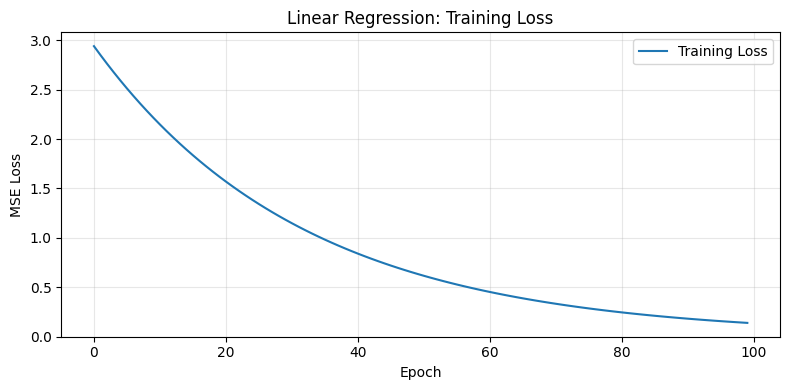


Linear Regression model successfully trained!


In [4]:
# Custom Training Loops
print("=" * 60)
print("Custom Training Loops")
print("=" * 60)

# 1. Simple linear regression with custom training
# Generate synthetic data: y = 2x + 1 + noise
np.random.seed(42)
x_data = np.random.randn(100, 1).astype(np.float32)
y_data = 2 * x_data + 1 + np.random.randn(100, 1) * 0.1

# Create model and optimizer
w = tf.Variable(tf.random.normal((1, 1)), trainable=True)
b = tf.Variable(tf.zeros((1,)), trainable=True)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

# Custom training step function
def train_step(x, y):
    with tf.GradientTape() as tape:
        # Forward pass
        predictions = tf.matmul(x, w) + b
        # MSE loss
        loss = tf.reduce_mean((predictions - y)**2)
    
    # Compute gradients
    gradients = tape.gradient(loss, [w, b])
    
    # Apply gradients
    optimizer.apply_gradients(zip(gradients, [w, b]))
    
    return loss

# Training loop
print("\nLinear Regression Training:")
print(f"Initial: w = {w.numpy().flatten()[0]:.4f}, b = {b.numpy()[0]:.4f}")

losses = []
for epoch in range(100):
    epoch_loss = train_step(x_data, y_data)
    losses.append(epoch_loss.numpy())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}: Loss = {epoch_loss.numpy():.6f}, w = {w.numpy().flatten()[0]:.4f}, b = {b.numpy()[0]:.4f}")

print(f"Final: w = {w.numpy().flatten()[0]:.4f} (target: 2.0), b = {b.numpy()[0]:.4f} (target: 1.0)")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Linear Regression: Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nLinear Regression model successfully trained!")

## Section 6: Custom Training Loops

**Why Custom Training Loops?**
- Full control over training process
- Implement custom loss functions and metrics
- Support non-standard architectures or learning strategies
- Debug training process step-by-step

**Basic Training Step:**
1. Forward pass: compute predictions
2. Compute loss
3. Compute gradients using GradientTape
4. Update weights using optimizer.apply_gradients()

In [5]:
# 3. Custom Model combining multiple layers
# Fallback for top-to-bottom notebook execution if CustomDense is defined later.
if 'CustomDense' not in globals():
    class CustomDense(tf.keras.layers.Layer):
        def __init__(self, units=32, activation=None):
            super().__init__()
            self.units = units
            self._dense = tf.keras.layers.Dense(units, activation=activation)

        def call(self, inputs):
            return self._dense(inputs)

class SimpleNN(tf.keras.Model):
    """Simple neural network with multiple custom layers"""
    
    def __init__(self, num_classes=10):
        super().__init__()
        self.dense1 = CustomDense(units=64, activation='relu')
        self.dropout1 = tf.keras.layers.Dropout(0.2)
        self.dense2 = CustomDense(units=32, activation='relu')
        self.dropout2 = tf.keras.layers.Dropout(0.2)
        self.output_layer = CustomDense(units=num_classes, activation=None)
    
    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dropout1(x, training=training)
        x = self.dense2(x)
        x = self.dropout2(x, training=training)
        return self.output_layer(x)

# Test custom model
print("\n\nCustom Sequential Model:")
model = SimpleNN(num_classes=10)

# Build model with dummy input
dummy_input = tf.random.normal((32, 28*28))  # MNIST-like input
output = model(dummy_input, training=True)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Total trainable parameters: {sum(v.numpy().size for v in model.trainable_variables)}")

# Display layer structure
print(f"\nModel Layers:")
for i, layer in enumerate(model.layers):
    print(f"  {i+1}. {layer.__class__.__name__}", end="")
    if hasattr(layer, 'units'):
        print(f" (units={layer.units})", end="")
    print()



Custom Sequential Model:
Input shape: (32, 784)
Output shape: (32, 10)
Total trainable parameters: 52650

Model Layers:
  1. CustomDense (units=64)
  2. Dropout
  3. CustomDense (units=32)
  4. Dropout
  5. CustomDense (units=10)


In [6]:
# Custom Layers and Models
print("=" * 60)
print("Custom Layers and Models")
print("=" * 60)

# 1. Simple custom layer - Dense layer
class CustomDense(tf.keras.layers.Layer):
    """Custom implementation of Dense layer: y = Wx + b"""
    
    def __init__(self, units=32, activation=None):
        super().__init__()
        self.units = units
        self.activation = tf.keras.activations.get(activation)
    
    def build(self, input_shape):
        # input_shape: (batch_size, input_dim)
        input_dim = input_shape[-1]
        
        # Create weights and biases
        self.w = self.add_weight(
            name='kernel',
            shape=(input_dim, self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)
    
    def call(self, inputs):
        # Forward pass: y = Wx + b
        output = tf.matmul(inputs, self.w) + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output
    
    def get_config(self):
        return {'units': self.units, 'activation': tf.keras.activations.serialize(self.activation)}

# Test custom dense layer
print("\nCustom Dense Layer:")
dense_layer = CustomDense(units=10, activation='relu')
test_input = tf.random.normal((4, 5))  # batch_size=4, input_dim=5
output = dense_layer(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Weight shape: {dense_layer.w.shape}")
print(f"Bias shape: {dense_layer.b.shape}")
print(f"Trainable parameters: {len(dense_layer.trainable_variables)}")

# 2. Custom layer with multiple operations
class ReLUWithDropout(tf.keras.layers.Layer):
    """ReLU activation with dropout"""
    
    def __init__(self, dropout_rate=0.2):
        super().__init__()
        self.dropout_rate = dropout_rate
    
    def call(self, inputs, training=False):
        # Apply ReLU
        output = tf.nn.relu(inputs)
        
        # Apply dropout during training
        if training:
            output = tf.nn.dropout(output, rate=self.dropout_rate)
        
        return output

relu_dropout = ReLUWithDropout(dropout_rate=0.2)
test_input = tf.constant([[-1.0, 2.0, -3.0], [4.0, -5.0, 6.0]])

print(f"\n\nReLU with Dropout:")
print(f"Input: {test_input}")
print(f"Output (inference): {relu_dropout(test_input, training=False)}")
print(f"Output (training, with dropout): {relu_dropout(test_input, training=True)}")

Custom Layers and Models

Custom Dense Layer:
Input shape: (4, 5)
Output shape: (4, 10)
Weight shape: (5, 10)
Bias shape: (10,)
Trainable parameters: 2


ReLU with Dropout:
Input: [[-1.  2. -3.]
 [ 4. -5.  6.]]
Output (inference): [[0. 2. 0.]
 [4. 0. 6.]]
Output (training, with dropout): [[0.  2.5 0. ]
 [5.  0.  7.5]]


## Section 5: Custom Layers and Models

**Why Custom Layers?**
- Encapsulate reusable neural network components
- Enable complex architectures with custom logic
- Support gradient computation through custom operations

**Layer Structure:**
- `__init__()`: Define parameters and sub-layers
- `build()`: Create layer parameters based on input shape
- `call()`: Forward pass computation

In [7]:
# 4. Higher-order gradients (second derivative)
x = tf.Variable(2.0)

# For f(x) = x^3, f'(x) = 3x^2, f''(x) = 6x
with tf.GradientTape() as tape2:
    with tf.GradientTape() as tape1:
        y = x**3
    
    # First derivative
    dy_dx = tape1.gradient(y, x)

# Second derivative
d2y_dx2 = tape2.gradient(dy_dx, x)
print(f"\n\nHigher-Order Gradients:")
print(f"Function: f(x) = x³")
print(f"At x = {x.numpy()}:")
print(f"  f(x) = {y.numpy()}")
print(f"  f'(x) = {dy_dx.numpy()}, Expected: 3x² = {3*2**2}")
print(f"  f''(x) = {d2y_dx2.numpy()}, Expected: 6x = {6*2}")

# 5. Persistent tape (allows multiple gradient computations)
x = tf.Variable(2.0)

with tf.GradientTape(persistent=True) as tape:
    y1 = x**2
    y2 = x**3

# Can call gradient multiple times with persistent tape
dy1_dx = tape.gradient(y1, x)
dy2_dx = tape.gradient(y2, x)

print(f"\n\nPersistent Tape (Multiple Gradients):")
print(f"At x = {x.numpy()}:")
print(f"  y₁ = x² = {y1.numpy()}, dy₁/dx = {dy1_dx.numpy()}")
print(f"  y₂ = x³ = {y2.numpy()}, dy₂/dx = {dy2_dx.numpy()}")

# Clean up persistent tape
del tape



Higher-Order Gradients:
Function: f(x) = x³
At x = 2.0:
  f(x) = 8.0
  f'(x) = 12.0, Expected: 3x² = 12
  f''(x) = 12.0, Expected: 6x = 12


Persistent Tape (Multiple Gradients):
At x = 2.0:
  y₁ = x² = 4.0, dy₁/dx = 4.0
  y₂ = x³ = 8.0, dy₂/dx = 12.0


In [8]:
# Automatic Differentiation with GradientTape
print("=" * 60)
print("Automatic Differentiation")
print("=" * 60)

# 1. Simple gradient computation
x = tf.Variable(3.0)  # Variable to compute gradient with respect to

with tf.GradientTape() as tape:
    # f(x) = x^2 + 3x + 2
    y = x**2 + 3*x + 2

# Compute gradient dy/dx
dy_dx = tape.gradient(y, x)
print(f"\nFunction: f(x) = x² + 3x + 2")
print(f"At x = {x.numpy()}:")
print(f"  f({x.numpy()}) = {y.numpy()}")
print(f"  f'({x.numpy()}) = {dy_dx.numpy()}")
print(f"  Expected: f'(x) = 2x + 3 = {2*3 + 3}")

# 2. Multiple variables
x = tf.Variable(2.0)
y = tf.Variable(3.0)

with tf.GradientTape() as tape:
    # z = x^2 + 2xy + y^2
    z = x**2 + 2*x*y + y**2

# Compute gradients for both variables
dz_dx, dz_dy = tape.gradient(z, [x, y])
print(f"\n\nFunction: z = x² + 2xy + y²")
print(f"At x = {x.numpy()}, y = {y.numpy()}:")
print(f"  z = {z.numpy()}")
print(f"  ∂z/∂x = {dz_dx.numpy()}, Expected: 2x + 2y = {2*2 + 2*3}")
print(f"  ∂z/∂y = {dz_dy.numpy()}, Expected: 2x + 2y = {2*2 + 2*3}")

# 3. Gradient of loss function (common in ML)
# MSE Loss: L = (1/n) * Σ(y_pred - y_true)²
y_true = tf.constant([1.0, 2.0, 3.0])
weights = tf.Variable([0.5, 0.5, 0.5])

with tf.GradientTape() as tape:
    y_pred = weights  # Simplified: prediction is just the weights
    mse_loss = tf.reduce_mean((y_pred - y_true)**2)

dL_dw = tape.gradient(mse_loss, weights)
print(f"\n\nMSE Loss Example:")
print(f"y_true = {y_true.numpy()}")
print(f"weights = {weights.numpy()}")
print(f"Loss = {mse_loss.numpy():.4f}")
print(f"∂L/∂w = {dL_dw.numpy()}")

Automatic Differentiation

Function: f(x) = x² + 3x + 2
At x = 3.0:
  f(3.0) = 20.0
  f'(3.0) = 9.0
  Expected: f'(x) = 2x + 3 = 9


Function: z = x² + 2xy + y²
At x = 2.0, y = 3.0:
  z = 25.0
  ∂z/∂x = 10.0, Expected: 2x + 2y = 10
  ∂z/∂y = 10.0, Expected: 2x + 2y = 10


MSE Loss Example:
y_true = [1. 2. 3.]
weights = [0.5 0.5 0.5]
Loss = 2.9167
∂L/∂w = [-0.33333334 -1.         -1.6666667 ]


## Section 4: Automatic Differentiation with GradientTape

**What is GradientTape?**
`tf.GradientTape` records operations on variables for automatic differentiation. It's essential for computing gradients during training.

**Key Concepts:**
- Records all operations inside the context
- Computes gradients using backward-mode automatic differentiation
- Supports nested tapes for higher-order gradients

**Mathematical Background:**
For a function $f(x) = x^2 + 3x + 2$, the derivative is $f'(x) = 2x + 3$

In [9]:
# Difference between Constants and Variables
print("=" * 60)
print("Constants vs Variables")
print("=" * 60)

# Constants - Immutable
constant = tf.constant([1.0, 2.0, 3.0])
print(f"\nConstant: {constant}")
print(f"Constant is trainable: False  # tf.Tensor has no .trainable; constants are always non-trainable")

# Try to modify - will fail
try:
    constant[0].assign(10.0)
except (TypeError, AttributeError) as e:
    print(f"Error modifying constant: {type(e).__name__}")

# Variables - Mutable
variable = tf.Variable([1.0, 2.0, 3.0])
print(f"\nVariable: {variable}")
print(f"Variable is trainable: {variable.trainable}")

# Modify variable
variable.assign([10.0, 20.0, 30.0])
print(f"After assign(): {variable}")

variable.assign_add([1.0, 1.0, 1.0])
print(f"After assign_add([1, 1, 1]): {variable}")

variable.assign_sub([2.0, 2.0, 2.0])
print(f"After assign_sub([2, 2, 2]): {variable}")

# Creating variables with different dtypes and shapes
print(f"\nCreating Variables with different configurations:")

# Float variable
float_var = tf.Variable(0.5, dtype=tf.float32, trainable=True)
print(f"Float variable: {float_var}, trainable={float_var.trainable}")

# Integer variable
int_var = tf.Variable(10, dtype=tf.int32, trainable=False)
print(f"Integer variable: {int_var}, trainable={int_var.trainable}")

# Matrix variable (useful for weights)
matrix_var = tf.Variable([[1.0, 2.0], [3.0, 4.0]])
print(f"Matrix variable:\n{matrix_var}")
print(f"Shape: {matrix_var.shape}, Trainable: {matrix_var.trainable}")

# Initialized from functions
zeros_var = tf.Variable(tf.zeros((3, 3)))
ones_var = tf.Variable(tf.ones((2, 2)))
random_var = tf.Variable(tf.random.normal((2, 2), mean=0.0, stddev=1.0))

print(f"\nZeros variable:\n{zeros_var}")
print(f"\nRandom normal variable:\n{random_var}")

Constants vs Variables

Constant: [1. 2. 3.]
Constant is trainable: False  # tf.Tensor has no .trainable; constants are always non-trainable
Error modifying constant: AttributeError

Variable: <tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>
Variable is trainable: True
After assign(): <tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([10., 20., 30.], dtype=float32)>
After assign_add([1, 1, 1]): <tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([11., 21., 31.], dtype=float32)>
After assign_sub([2, 2, 2]): <tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([ 9., 19., 29.], dtype=float32)>

Creating Variables with different configurations:
Float variable: <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=0.5>, trainable=True
Integer variable: <tf.Variable 'Variable:0' shape=() dtype=int32, numpy=10>, trainable=False
Matrix variable:
<tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array

## Section 3: Variables and Constants

**Constants vs Variables:**
- **tf.constant()**: Immutable tensors, cannot be modified after creation
- **tf.Variable()**: Mutable tensors, can be updated using `.assign()`, `.assign_add()`, etc.

**Use Cases:**
- Constants: Input data, model hyperparameters (learning rates that don't change)
- Variables: Model weights, biases, any learnable parameters

In [10]:
# Indexing and Slicing
print("\n" + "=" * 60)
print("Indexing and Slicing")
print("=" * 60)

# 1D indexing and slicing
vector = tf.constant([10, 20, 30, 40, 50])
print(f"\nVector: {vector}")
print(f"  First element: {vector[0]}")
print(f"  Last element: {vector[-1]}")
print(f"  Elements [1:3]: {vector[1:3]}")
print(f"  Every other element [::2]: {vector[::2]}")

# 2D indexing and slicing
matrix = tf.constant([[1, 2, 3, 4],
                      [5, 6, 7, 8],
                      [9, 10, 11, 12]])
print(f"\nMatrix shape {matrix.shape}:")
print(f"{matrix}")
print(f"  Element [1, 2]: {matrix[1, 2]}")
print(f"  First row: {matrix[0, :]}")
print(f"  First column: {matrix[:, 0]}")
print(f"  Submatrix [1:3, 1:3]:\n{matrix[1:3, 1:3]}")

# Reshaping
print(f"\nReshaping:")
original = tf.constant([1, 2, 3, 4, 5, 6])
reshaped = tf.reshape(original, (2, 3))
print(f"Original shape {original.shape}: {original}")
print(f"Reshaped to (2, 3):\n{reshaped}")


Indexing and Slicing

Vector: [10 20 30 40 50]
  First element: 10
  Last element: 50
  Elements [1:3]: [20 30]
  Every other element [::2]: [10 30 50]

Matrix shape (3, 4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
  Element [1, 2]: 7
  First row: [1 2 3 4]
  First column: [1 5 9]
  Submatrix [1:3, 1:3]:
[[ 6  7]
 [10 11]]

Reshaping:
Original shape (6,): [1 2 3 4 5 6]
Reshaped to (2, 3):
[[1 2 3]
 [4 5 6]]


In [11]:
# Basic Math Operations
print("\n" + "=" * 60)
print("Basic Math Operations")
print("=" * 60)

a = tf.constant([1.0, 2.0, 3.0])
b = tf.constant([4.0, 5.0, 6.0])

# Element-wise operations
add_result = tf.add(a, b)
sub_result = tf.subtract(a, b)
mul_result = tf.multiply(a, b)
div_result = tf.divide(b, a)

print(f"\nAddition: {a} + {b} = {add_result}")
print(f"Subtraction: {b} - {a} = {sub_result}")
print(f"Multiplication: {a} * {b} = {mul_result}")
print(f"Division: {b} / {a} = {div_result}")

# Using Python operators (equivalent to above)
print(f"\nUsing operators:")
print(f"Addition (a + b): {a + b}")
print(f"Subtraction (b - a): {b - a}")
print(f"Multiplication (a * b): {a * b}")
print(f"Division (b / a): {b / a}")

# Matrix multiplication
matrix_a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
matrix_b = tf.constant([[5.0, 6.0], [7.0, 8.0]])

matmul_result = tf.matmul(matrix_a, matrix_b)
print(f"\nMatrix Multiplication:")
print(f"A:\n{matrix_a}")
print(f"B:\n{matrix_b}")
print(f"A @ B:\n{matmul_result}")

# Reduction operations
values = tf.constant([1.0, 2.0, 3.0, 4.0, 5.0])
print(f"\nReduction Operations on {values.numpy()}:")
print(f"  Sum: {tf.reduce_sum(values)}")
print(f"  Mean: {tf.reduce_mean(values)}")
print(f"  Max: {tf.reduce_max(values)}")
print(f"  Min: {tf.reduce_min(values)}")


Basic Math Operations

Addition: [1. 2. 3.] + [4. 5. 6.] = [5. 7. 9.]
Subtraction: [4. 5. 6.] - [1. 2. 3.] = [-3. -3. -3.]
Multiplication: [1. 2. 3.] * [4. 5. 6.] = [ 4. 10. 18.]
Division: [4. 5. 6.] / [1. 2. 3.] = [4.  2.5 2. ]

Using operators:
Addition (a + b): [5. 7. 9.]
Subtraction (b - a): [3. 3. 3.]
Multiplication (a * b): [ 4. 10. 18.]
Division (b / a): [4.  2.5 2. ]

Matrix Multiplication:
A:
[[1. 2.]
 [3. 4.]]
B:
[[5. 6.]
 [7. 8.]]
A @ B:
[[19. 22.]
 [43. 50.]]

Reduction Operations on [1. 2. 3. 4. 5.]:
  Sum: 15.0
  Mean: 3.0
  Max: 5.0
  Min: 1.0


In [12]:
# Creating tensors using different methods
print("=" * 60)
print("Creating Tensors")
print("=" * 60)

# 1. Using tf.constant() - Creates immutable tensors
scalar = tf.constant(5)
vector = tf.constant([1, 2, 3, 4, 5])
matrix = tf.constant([[1, 2, 3], [4, 5, 6]])

print(f"\nScalar (Rank 0): {scalar}")
print(f"  Shape: {scalar.shape}, Dtype: {scalar.dtype}")

print(f"\nVector (Rank 1): {vector}")
print(f"  Shape: {vector.shape}, Dtype: {vector.dtype}")

print(f"\nMatrix (Rank 2):\n{matrix}")
print(f"  Shape: {matrix.shape}, Dtype: {matrix.dtype}")

# 2. Using tf.zeros() and tf.ones()
zeros = tf.zeros((3, 3))
ones = tf.ones((2, 4), dtype=tf.float32)

print(f"\nZeros tensor (3x3):\n{zeros}")
print(f"\nOnes tensor (2x4):\n{ones}")

# 3. Using tf.range() - Similar to Python range
range_tensor = tf.range(0, 10, 2)
print(f"\nRange tensor (0 to 10, step 2): {range_tensor}")

# 4. Using tf.linspace() - Linearly spaced values
linspace_tensor = tf.linspace(0.0, 10.0, 5)
print(f"Linspace tensor (0 to 10, 5 values): {linspace_tensor}")

# 5. Converting from NumPy
numpy_array = np.array([1.5, 2.5, 3.5])
tensor_from_numpy = tf.convert_to_tensor(numpy_array)
print(f"\nTensor from NumPy: {tensor_from_numpy}")
print(f"  Dtype: {tensor_from_numpy.dtype}")

Creating Tensors

Scalar (Rank 0): 5
  Shape: (), Dtype: <dtype: 'int32'>

Vector (Rank 1): [1 2 3 4 5]
  Shape: (5,), Dtype: <dtype: 'int32'>

Matrix (Rank 2):
[[1 2 3]
 [4 5 6]]
  Shape: (2, 3), Dtype: <dtype: 'int32'>

Zeros tensor (3x3):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Ones tensor (2x4):
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]]

Range tensor (0 to 10, step 2): [0 2 4 6 8]
Linspace tensor (0 to 10, 5 values): [ 0.   2.5  5.   7.5 10. ]

Tensor from NumPy: [1.5 2.5 3.5]
  Dtype: <dtype: 'float64'>


## Section 2: Tensors and Basic Operations

**What is a Tensor?**
A tensor is a multi-dimensional array of numbers. It's the fundamental data structure in TensorFlow:
- **Rank 0**: Scalar (single value) - `tf.constant(5)`
- **Rank 1**: Vector (1D array) - `tf.constant([1, 2, 3])`
- **Rank 2**: Matrix (2D array) - `tf.constant([[1, 2], [3, 4]])`
- **Rank 3+**: Higher-order tensors

**Key Properties:**
- Shape: Dimensions of the tensor
- Dtype: Data type (float32, int32, etc.)
- NumPy conversion: `.numpy()` method

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

# Print TensorFlow version
print(f"TensorFlow Version: {tf.__version__}")

# Check available devices (CPU/GPU)
devices = tf.config.list_physical_devices()
print(f"\nAvailable devices:")
for device in devices:
    print(f"  - {device}")

# Specifically check for GPUs
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPU Devices: {len(gpus)}")
for gpu in gpus:
    print(f"  - {gpu}")

# Enable memory growth for GPU (avoid OOM errors)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Memory growth enabled for {gpu}")
    except RuntimeError as e:
        print(f"Memory growth already enabled or GPU not available: {e}")

TensorFlow Version: 2.22.0-dev0+selfbuilt

Available devices:
  - PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU Devices: 1
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Memory growth already enabled or GPU not available: Physical devices cannot be modified after being initialized


## Section 1: Import and Setup TensorFlow

This section imports TensorFlow, verifies installation, checks GPU availability, and configures device placement.

# TensorFlow Core Library: Basics, Operations & Automatic Differentiation

## Overview
This notebook provides a comprehensive guide to TensorFlow core library fundamentals:
- **Tensor Creation & Operations**: Understanding tensors, shapes, and basic math operations
- **Variables and Constants**: Managing trainable and non-trainable parameters
- **Automatic Differentiation**: Computing gradients using GradientTape
- **Custom Layers & Models**: Building custom neural network components
- **Custom Training Loops**: Implementing training from scratch
- **Edge Cases**: Handling NaN, Inf, shape mismatches, and type casting

**References:**
- [TensorFlow Official Guide](https://www.tensorflow.org/guide)
- [TensorFlow Core API Documentation](https://www.tensorflow.org/api_docs/python/tf)
- [Advanced Autodiff](https://www.tensorflow.org/guide/autodiff)